In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
zip="/content/drive/MyDrive/Deep LEarning/garbage_data.zip"

In [ ]:
import zipfile

with zipfile.ZipFile(zip, 'r') as zip_ref:
    zip_ref.extractall("/content/garbage_data")

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
# Set the image folder path (update if needed)
data_path = '/content/garbage_data/Garbage classification/Garbage classification'

# Set image size and batch size
img_size = (150, 150)
batch_size = 32

In [ ]:
# Create ImageDataGenerator with 20% validation split
datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# Load training data
train_data = datagen.flow_from_directory(
    data_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

# Load validation data
val_data = datagen.flow_from_directory(
    data_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)


Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build the model
model = Sequential([
    # First Convolutional Block
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    # Second Convolutional Block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Third Convolutional Block
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Flatten and Dense Layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),  # Helps prevent overfitting
    Dense(6, activation='softmax')  # 6 output classes
])



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
# Train the model for 10 epochs
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.3093 - loss: 1.6958

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 316ms/step - accuracy: 0.3103 - loss: 1.6938 - val_accuracy: 0.3499 - val_loss: 1.5479
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 249ms/step - accuracy: 0.4363 - loss: 1.3450 - val_accuracy: 0.4433 - val_loss: 1.4209
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 279ms/step - accuracy: 0.5103 - loss: 1.2206 - val_accuracy: 0.4433 - val_loss: 1.4217
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 248ms/step - accuracy: 0.5688 - loss: 1.1263 - val_accuracy: 0.5229 - val_loss: 1.2691
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 247ms/step - accuracy: 0.6080 - loss: 1.0392 - val_accuracy: 0.4573 - val_loss: 1.4201
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 247ms/step - accuracy: 0.6238 - loss: 1.0152 - val_accuracy: 0.5050 - val_loss: 1.3316
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 284ms/step - accuracy: 0.6125 - loss: 1.0277 - val_accuracy: 0.5527 - val_loss: 1.2057
Epoch 8/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 248ms/step - accuracy: 0.6729 - loss: 0.9306 - val_accuracy: 0.552

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving metal6.jpg to metal6.jpg


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Replace 'test_image.jpg' with your uploaded file name
img = image.load_img("metal6.jpg", target_size=(150, 150))  # Match the same size used in training
img_array = image.img_to_array(img) / 255.0                     # Normalize like training data
img_array = np.expand_dims(img_array, axis=0)                   # Add batch dimension

# Predict using the trained model
prediction = model.predict(img_array)

# Get class names from training data
class_names = list(train_data.class_indices.keys())

# Output the prediction
predicted_class = class_names[np.argmax(prediction)]
print("Predicted Class:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted Class: glass


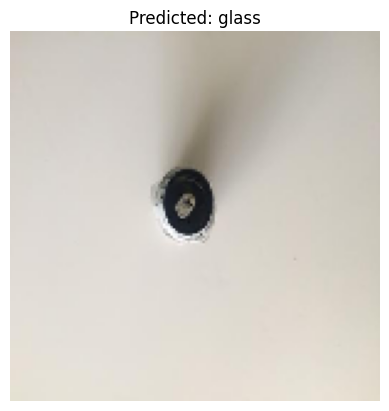

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted: {predicted_class}")
plt.show()
